In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls -la "/content/drive/MyDrive/Personal_Thesis_USTH/Dataset/"

total 5145411
-rw------- 1 root root       1860 Apr  1 17:26 DataPreprocessing.ipynb
-rw------- 1 root root       2681 Apr  4 13:44 Dataset.ipynb
-rw------- 1 root root 5268895642 Mar 18 17:59 MVTecAD.zip


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Personal_Thesis_USTH/Dataset/MVTecAD.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted Done")

Extracted Done


In [ ]:
!ls -la "/content/dataset"

total 96
drwxr-xr-x 17 root root  4096 Apr  4 13:46 .
drwxr-xr-x  1 root root  4096 Apr  4 13:44 ..
drwxr-xr-x  5 root root  4096 Apr  4 13:44 bottle
drwxr-xr-x  5 root root  4096 Apr  4 13:44 cable
drwxr-xr-x  5 root root  4096 Apr  4 13:45 capsule
drwxr-xr-x  5 root root  4096 Apr  4 13:45 carpet
drwxr-xr-x  5 root root  4096 Apr  4 13:45 grid
drwxr-xr-x  5 root root  4096 Apr  4 13:45 hazelnut
drwxr-xr-x  5 root root  4096 Apr  4 13:45 leather
-rw-r--r--  1 root root 20845 Apr  4 13:45 license.txt
drwxr-xr-x  5 root root  4096 Apr  4 13:45 metal_nut
drwxr-xr-x  5 root root  4096 Apr  4 13:45 pill
-rw-r--r--  1 root root   881 Apr  4 13:45 readme.txt
drwxr-xr-x  5 root root  4096 Apr  4 13:45 screw
drwxr-xr-x  5 root root  4096 Apr  4 13:45 tile
drwxr-xr-x  5 root root  4096 Apr  4 13:46 toothbrush
drwxr-xr-x  5 root root  4096 Apr  4 13:46 transistor
drwxr-xr-x  5 root root  4096 Apr  4 13:46 wood
drwxr-xr-x  5 root root  4096 Apr  4 13:46 zipper


In [ ]:
!find "/content/dataset" -type d -name "metal_nut"

/content/dataset/metal_nut


In [ ]:
data_root = "/content/dataset/metal_nut"

!ls "$data_root/train"
!ls "$data_root/test"

good
bent  color  flip  good  scratch


In [ ]:
import glob

train_normal = glob.glob(f"{data_root}/train/good/*.png")
print(f"Number image train good: {len(train_normal)}")

for defect_type in ["good", "scratch", "bent", "color", "flip"]:
    test_imgs = glob.glob(f"{data_root}/test/{defect_type}/*.png")
    print(f"Test {defect_type}: {len(test_imgs)}")

Number image train good: 220
Test good: 22
Test scratch: 23
Test bent: 25
Test color: 22
Test flip: 23


In [ ]:
from PIL import Image
import glob
sample_img = Image.open(glob.glob(f"{data_root}/train/good/*.png")[0])
print(sample_img.size)

(700, 700)


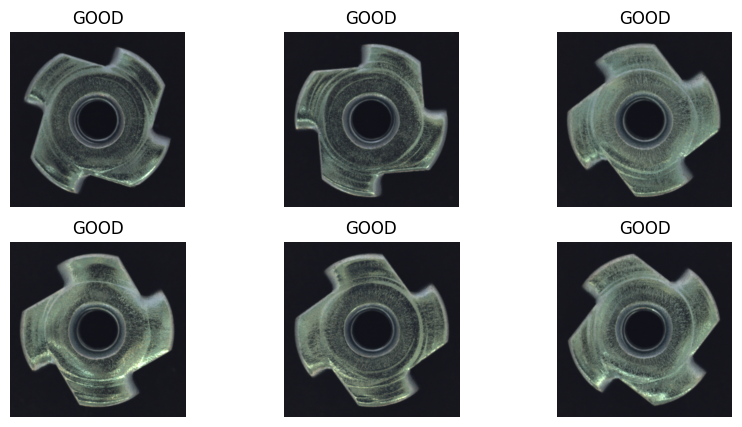

In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image

good_imgs = glob.glob(f"{data_root}/train/good/*.png")

samples = random.sample(good_imgs, 6)

plt.figure(figsize=(10,5))

for i, img_path in enumerate(samples):
    img = Image.open(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("GOOD")

plt.show()

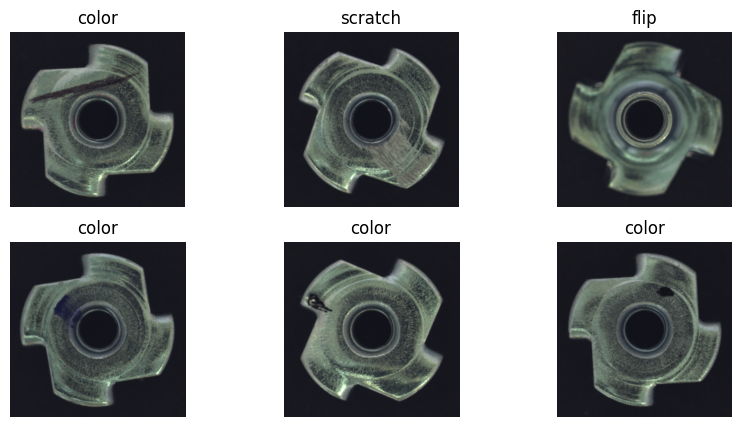

In [ ]:
defect_imgs = []

for defect in ["scratch", "bent", "color", "flip"]:
    defect_imgs += glob.glob(f"{data_root}/test/{defect}/*.png")

samples = random.sample(defect_imgs, 6)

plt.figure(figsize=(10,5))

for i, img_path in enumerate(samples):
    img = Image.open(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.split("/")[-2])

plt.show()

In [ ]:
import os
import glob

train_normal = glob.glob(f"{data_root}/train/good/*.png")
print(f"Number image train good: {len(train_normal)}")

test_defect_types = sorted(os.listdir(f"{data_root}/test"))

for defect_type in test_defect_types:
    test_imgs = glob.glob(f"{data_root}/test/{defect_type}/*.png")
    print(f"Test {defect_type}: {len(test_imgs)}")

Number image train good: 220
Test bent: 25
Test color: 22
Test flip: 23
Test good: 22
Test scratch: 23
